# 01 - Metrics Anomaly Detection

Notebook này phân tích metrics của `cart-service` để so sánh Z-score và Isolation Forest, và tạo chart so sánh hai phương pháp.

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

BASE = Path(r"D:\\AWS\\AIOPS-study\\g2-data\\g2\\metrics")
ART = Path(r"D:\\AWS\\AIOPS\\w1\\lab\\artifacts")
ART.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8')

In [ ]:
cart = pd.read_csv(BASE / 'cart-service.csv', parse_dates=['timestamp'])
cart = cart.ffill().fillna(0)
cart.head()

,timestamp,memory_usage_bytes,memory_limit_bytes,cpu_usage_percent,http_requests_per_sec,http_p99_latency_ms,http_5xx_rate,jvm_gc_pause_ms_avg,container_restart_count
0,2026-06-01 00:00:00+00:00,426047268,2147483648,26.59,38.18,39.7,1.78,32.2,0
1,2026-06-01 00:00:30+00:00,402781115,2147483648,26.15,42.27,50.6,0.00,36.5,0
2,2026-06-01 00:01:00+00:00,408265869,2147483648,22.09,46.06,44.9,0.92,58.8,0
3,2026-06-01 00:01:30+00:00,338915261,2147483648,10.61,39.45,47.9,0.00,13.0,0
4,2026-06-01 00:02:00+00:00,488996520,2147483648,15.56,42.13,32.5,1.22,46.8,0


In [ ]:
base = cart.iloc[:720]
mem_mean, mem_std = base['memory_usage_bytes'].mean(), base['memory_usage_bytes'].std()
gc_mean, gc_std = base['jvm_gc_pause_ms_avg'].mean(), base['jvm_gc_pause_ms_avg'].std()
lat_mean, lat_std = base['http_p99_latency_ms'].mean(), base['http_p99_latency_ms'].std()
err_mean, err_std = base['http_5xx_rate'].mean(), base['http_5xx_rate'].std()

for col, mean, std in [
    ('memory_usage_bytes', mem_mean, mem_std),
    ('jvm_gc_pause_ms_avg', gc_mean, gc_std),
    ('http_p99_latency_ms', lat_mean, lat_std),
    ('http_5xx_rate', err_mean, err_std),
]:
    z = (cart[col] - mean) / std
    cart[f'{col}_z'] = z
    cart[f'{col}_z_anomaly'] = z.abs() > 3

zscore_results = pd.DataFrame([
    {
        'metric': col,
        'first_anomaly': cart.loc[cart[f'{col}_z_anomaly'], 'timestamp'].min(),
        'points_flagged': int(cart[f'{col}_z_anomaly'].sum()),
        'pct_flagged': round(cart[f'{col}_z_anomaly'].mean() * 100, 2),
    }
    for col in ['memory_usage_bytes', 'jvm_gc_pause_ms_avg', 'http_p99_latency_ms', 'http_5xx_rate']
])
zscore_results

,metric,first_anomaly,points_flagged,pct_flagged
0,memory_usage_bytes,2026-06-01 08:07:30+00:00,624,22.13
1,jvm_gc_pause_ms_avg,2026-06-01 09:22:00+00:00,244,8.65
2,http_p99_latency_ms,2026-06-01 00:47:00+00:00,1086,38.51
3,http_5xx_rate,2026-06-01 20:25:30+00:00,359,12.73


In [ ]:
features = ['memory_usage_bytes', 'jvm_gc_pause_ms_avg', 'http_p99_latency_ms', 'http_5xx_rate']
X = StandardScaler().fit_transform(cart[features])
model = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
model.fit(X[:1440])
cart['if_score'] = -model.decision_function(X)
cart['if_anomaly'] = model.predict(X) == -1
iforest_results = pd.DataFrame([
    {
        'first_anomaly': cart.loc[cart['if_anomaly'], 'timestamp'].min(),
        'points_flagged': int(cart['if_anomaly'].sum()),
        'alert_score': float(cart.loc[cart['timestamp'] == pd.Timestamp('2026-06-01T23:04:00Z'), 'if_score'].iloc[0]),
    }
])
iforest_results

,first_anomaly,points_flagged,alert_score
0,2026-06-01 00:12:00+00:00,1176,0.073629


In [ ]:
comparison = pd.DataFrame([
    {
        'Metric': 'First anomaly detected',
        'Z-score': zscore_results['first_anomaly'].min(),
        'Isolation Forest': iforest_results['first_anomaly'].iloc[0],
    },
    {
        'Metric': 'Total points flagged',
        'Z-score': int(zscore_results['points_flagged'].sum()),
        'Isolation Forest': int(iforest_results['points_flagged'].iloc[0]),
    },
    {
        'Metric': 'False positive estimate (before 15:00)',
        'Z-score': int((cart[cart['timestamp'] < pd.Timestamp('2026-06-01T15:00:00Z')]['memory_usage_bytes_z_anomaly']).sum() + (cart[cart['timestamp'] < pd.Timestamp('2026-06-01T15:00:00Z')]['jvm_gc_pause_ms_avg_z_anomaly']).sum() + (cart[cart['timestamp'] < pd.Timestamp('2026-06-01T15:00:00Z')]['http_p99_latency_ms_z_anomaly']).sum() + (cart[cart['timestamp'] < pd.Timestamp('2026-06-01T15:00:00Z')]['http_5xx_rate_z_anomaly']).sum()),
        'Isolation Forest': int(cart[(cart['timestamp'] < pd.Timestamp('2026-06-01T15:00:00Z')) & cart['if_anomaly']].shape[0]),
    },
    {
        'Metric': 'Minutes before alert fired',
        'Z-score': int((pd.Timestamp('2026-06-01T23:04:00Z') - zscore_results['first_anomaly'].min()).total_seconds() // 60),
        'Isolation Forest': int((pd.Timestamp('2026-06-01T23:04:00Z') - iforest_results['first_anomaly'].iloc[0]).total_seconds() // 60),
    },
])
comparison

,Metric,Z-score,Isolation Forest
0,First anomaly detected,2026-06-01 00:47:00+00:00,2026-06-01 00:12:00+00:00
1,Total points flagged,2313,1176
2,False positive estimate (before 15:00),63,128
3,Minutes before alert fired,1337,1372


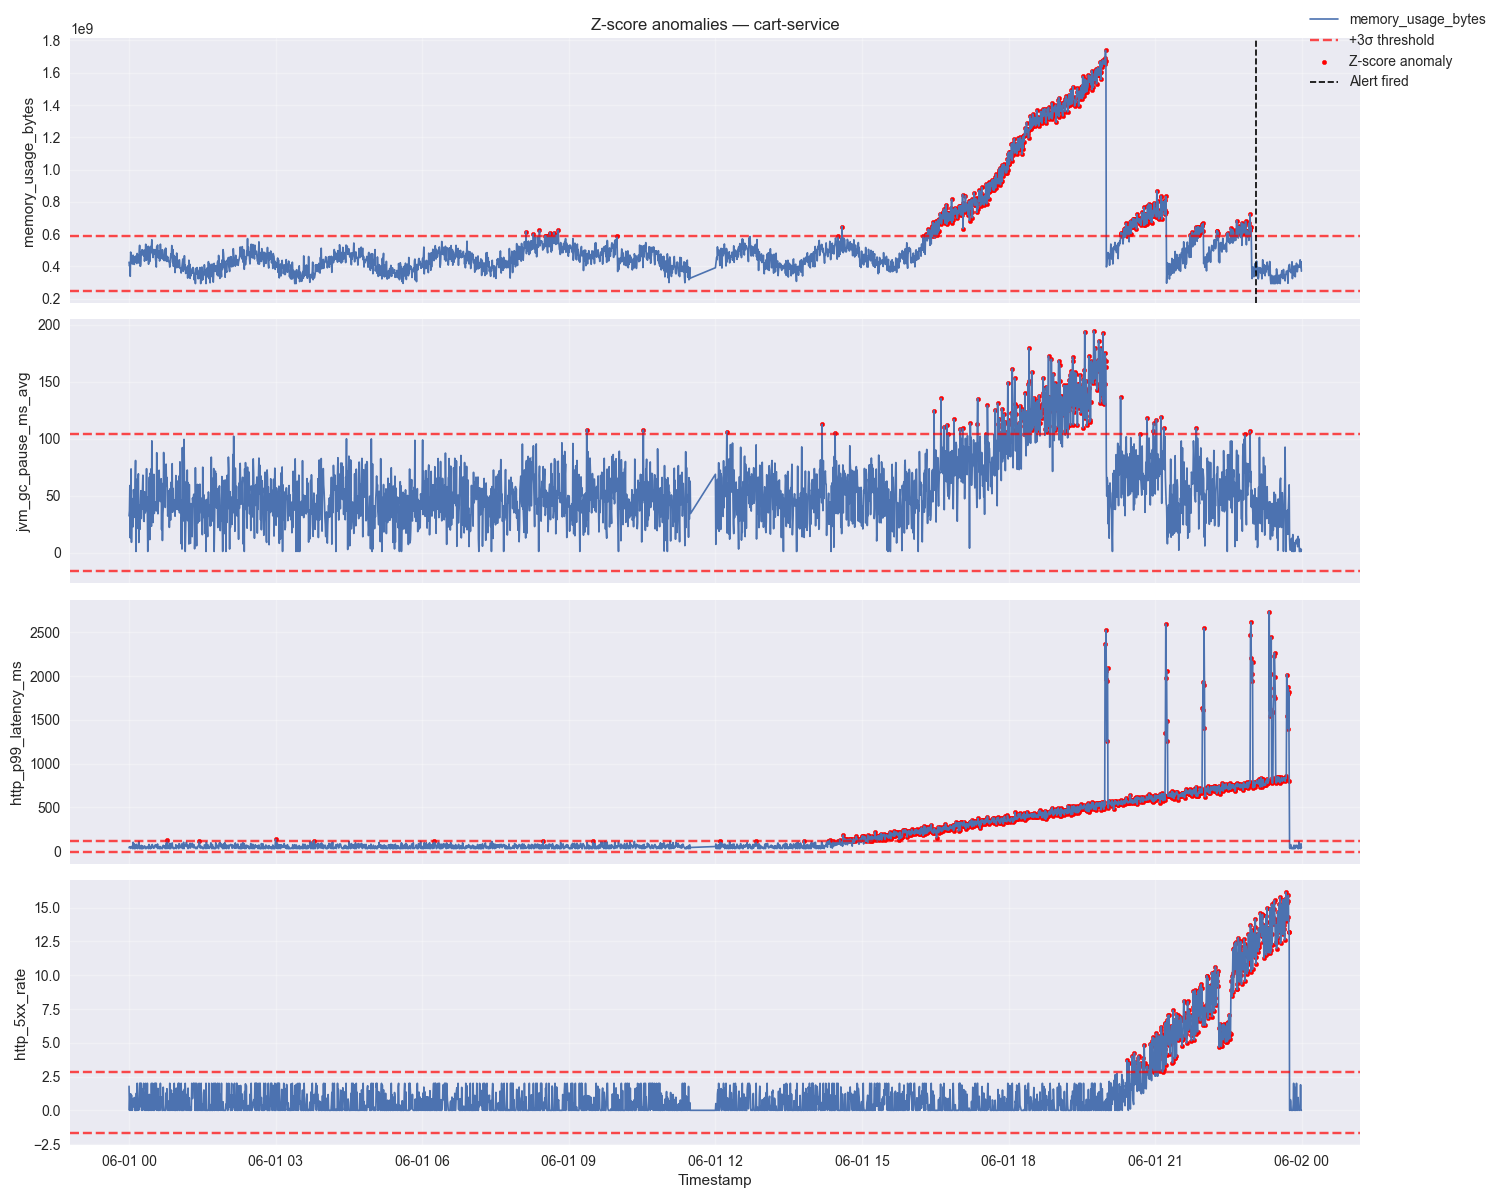

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
alert = pd.Timestamp('2026-06-01T23:04:00Z')

for i, col in enumerate(features):
    ax[i].plot(cart['timestamp'], cart[col], label=col, linewidth=1.2)
    ax[i].axhline(base[col].mean() + 3 * base[col].std(), color='red', linestyle='--', alpha=0.7, label='+3σ threshold' if i == 0 else None)
    ax[i].axhline(base[col].mean() - 3 * base[col].std(), color='red', linestyle='--', alpha=0.7)
    ax[i].scatter(cart.loc[cart[f'{col}_z_anomaly'], 'timestamp'], cart.loc[cart[f'{col}_z_anomaly'], col], color='red', s=10, label='Z-score anomaly' if i == 0 else None)
    ax[i].set_ylabel(col)
    ax[i].grid(True, alpha=0.3)

ax[0].axvline(alert, color='black', linestyle='--', linewidth=1.2, label='Alert fired')
ax[0].set_title('Z-score anomalies — cart-service')
ax[-1].set_xlabel('Timestamp')
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
fig.tight_layout(rect=[0, 0, 0.92, 1])
fig.savefig(ART / 'chart_04_zscore_visual.png', dpi=150, bbox_inches='tight')
plt.show()


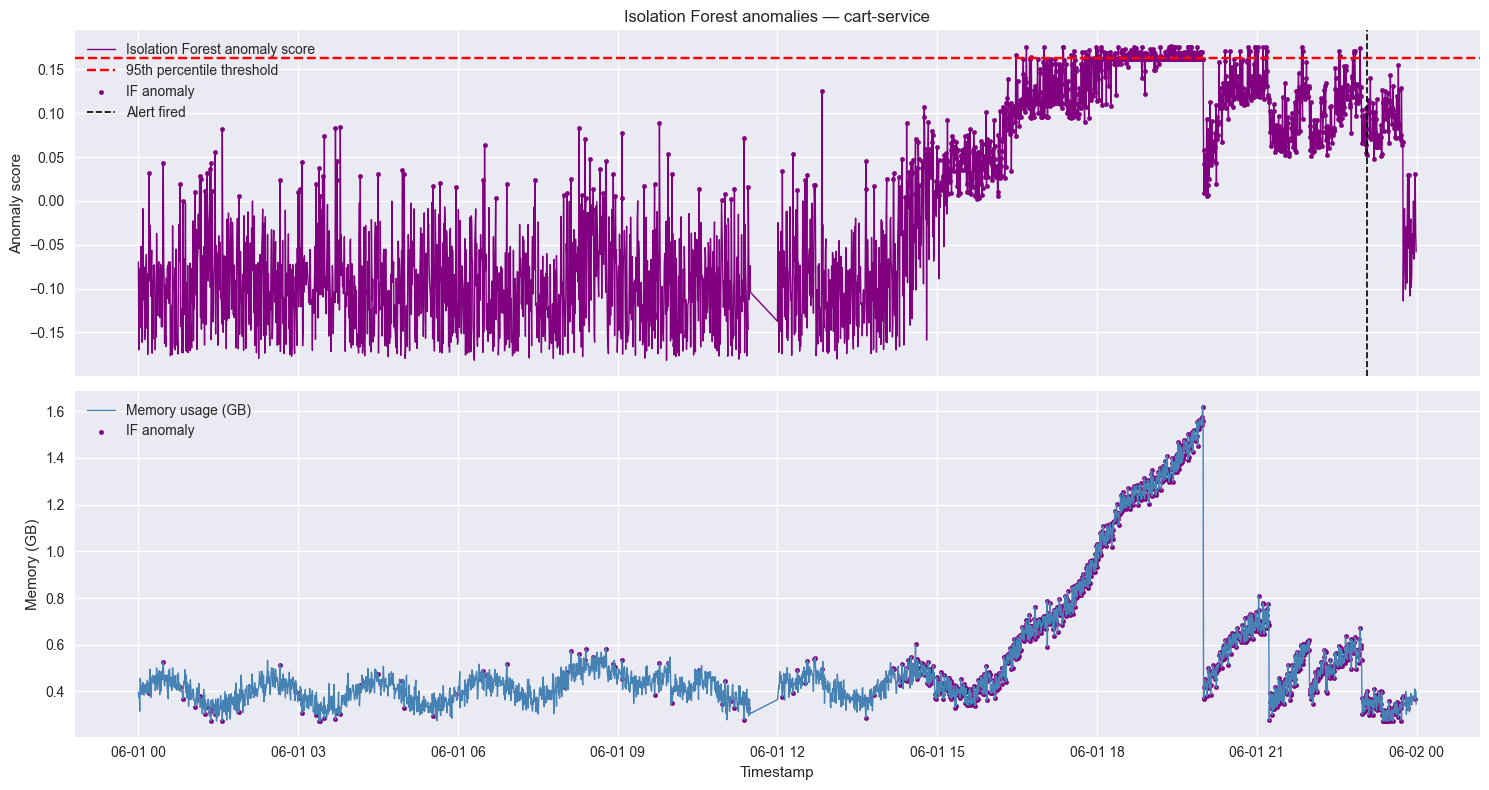

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
ax[0].plot(cart['timestamp'], cart['if_score'], color='purple', linewidth=1.0, label='Isolation Forest anomaly score')
ax[0].axhline(cart['if_score'].quantile(0.95), color='red', linestyle='--', label='95th percentile threshold')
ax[0].scatter(cart.loc[cart['if_anomaly'], 'timestamp'], cart.loc[cart['if_anomaly'], 'if_score'], color='purple', s=10, label='IF anomaly')
ax[0].axvline(alert, color='black', linestyle='--', linewidth=1.2, label='Alert fired')
ax[0].set_title('Isolation Forest anomalies — cart-service')
ax[0].set_ylabel('Anomaly score')
ax[0].legend(loc='upper left')

ax[1].plot(cart['timestamp'], cart['memory_usage_bytes'] / (1024**3), color='steelblue', linewidth=1.0, label='Memory usage (GB)')
ax[1].scatter(cart.loc[cart['if_anomaly'], 'timestamp'], cart.loc[cart['if_anomaly'], 'memory_usage_bytes'] / (1024**3), color='purple', s=10, label='IF anomaly')
ax[1].set_ylabel('Memory (GB)')
ax[1].set_xlabel('Timestamp')
ax[1].legend(loc='upper left')
fig.tight_layout()
fig.savefig(ART / 'chart_04_iforest_visual.png', dpi=150, bbox_inches='tight')
plt.show()


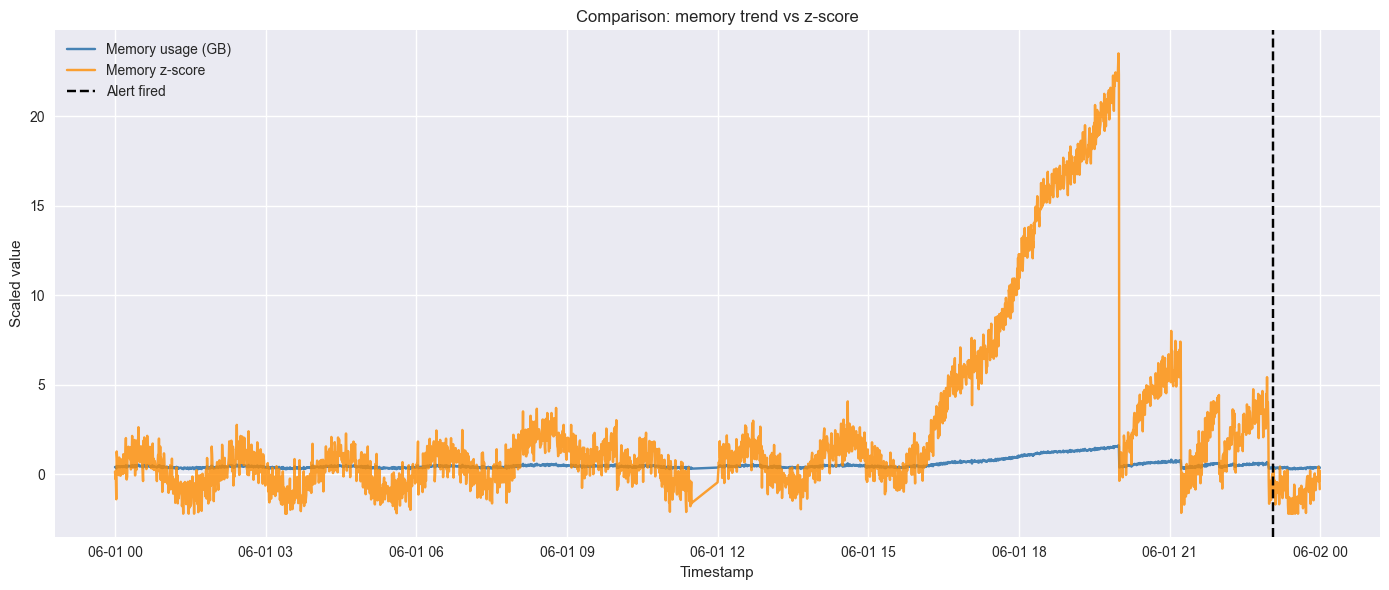

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(cart['timestamp'], cart['memory_usage_bytes'] / (1024**3), label='Memory usage (GB)', color='steelblue')
ax.plot(cart['timestamp'], cart['memory_usage_bytes_z'], label='Memory z-score', color='darkorange', alpha=0.8)
ax.axvline(alert, color='black', linestyle='--', label='Alert fired')
ax.set_title('Comparison: memory trend vs z-score')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Scaled value')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(ART / 'chart_04_anomaly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Kết luận chính:
- Z-score phát hiện rất sớm các điểm lệch trong memory/GC nhưng có thể nhạy với spike lẻ.
- Isolation Forest cho tín hiệu đa biến, bám tốt hơn vào mẫu anomaly lan truyền của incident.
- Vì bài này là restart loop do memory pressure kéo dài, sustained anomaly và đa biến là quan trọng nhất.